In [ ]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback, RobertaModel, RobertaTokenizer
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.cluster import DBSCAN
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=False)

Mounted at /content/drive/


In [ ]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [ ]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999 entries, 20 to 61821
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2999 non-null   object 
 1   country                             2999 non-null   object 
 2   contest_url                         2999 non-null   object 
 3   num_of_contest                      2999 non-null   int64  
 4   is_weekly                           2999 non-null   bool   
 5   rank                                2999 non-null   int64  
 6   score                               2999 non-null   int64  
 7   question_number                     2999 non-null   int64  
 8   question_language                   2999 non-null   object 
 9   question_code                       2999 non-null   object 
 10  number_of_lines                     2999 non-null   int64  
 11  names_set                           2999 non-n

<Axes: >

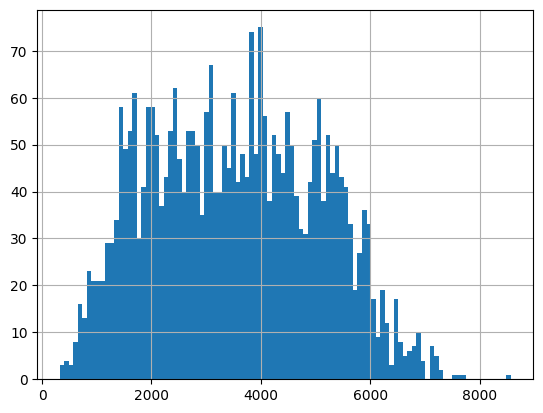

In [ ]:
leetcode_questions_df.contest_finish_time_total_seconds.hist(bins=100)

In [ ]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,300
False,300


In [ ]:
leetcode_questions_df = filtered_df

In [ ]:
leetcode_questions_df.describe()

,num_of_contest,rank,score,question_number,number_of_lines,token_count,variables_count,function_count,loop_count,condition_count,...,function_density,loop_density,condition_density,comment_tokens_density,contest_finish_time_total_seconds,question_finish_time_total_seconds,time_spent_per_question,global_rank_percentile,question_code_length,num_contests_participated
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,...,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,284.626667,606.956667,15.291667,3.320000,74.673333,46.781667,25.520000,4.06500,4.800000,6.593333,...,0.051564,0.087768,0.110414,0.088365,3632.128333,2479.851667,1180.896667,0.024536,2159.198333,10.588333
std,125.305772,344.768619,3.105802,0.466865,265.088765,63.031624,36.307989,19.87618,13.570812,22.666073,...,0.037712,0.063429,0.071215,0.168463,2527.617146,1774.466462,1107.251725,0.079768,7660.892041,9.365275
min,116.000000,1.000000,8.000000,3.000000,8.000000,11.000000,5.000000,1.00000,0.000000,0.000000,...,0.006993,0.000000,0.000000,0.000000,326.000000,179.000000,0.000000,0.000001,109.000000,1.000000
25%,124.000000,343.750000,12.000000,3.000000,29.000000,30.000000,16.000000,1.00000,2.000000,2.000000,...,0.030303,0.045285,0.058824,0.000000,1191.750000,1016.500000,366.500000,0.000266,856.500000,3.000000
50%,372.000000,631.500000,17.000000,3.000000,42.000000,37.000000,20.000000,2.00000,3.000000,4.000000,...,0.043478,0.078947,0.100000,0.000000,3532.000000,1462.000000,725.000000,0.001755,1230.500000,7.000000
75%,383.000000,880.000000,18.000000,4.000000,60.000000,46.000000,26.000000,2.00000,5.000000,6.000000,...,0.061224,0.115385,0.150000,0.115135,5981.000000,4481.500000,1745.750000,0.012281,1722.000000,17.000000
max,390.000000,1224.000000,19.000000,4.000000,2770.000000,655.000000,383.000000,208.00000,144.000000,250.000000,...,0.320988,0.521739,0.457143,0.859155,8568.000000,5391.000000,5219.000000,0.828094,80163.000000,34.000000


In [ ]:
X=leetcode_questions_df.drop('experienced_programmer',axis=1)
Y=leetcode_questions_df.experienced_programmer.astype(int)

In [ ]:
X_train_text, X_test_text, Y_train, y_test = train_test_split(X.question_code, Y, test_size=0.2, random_state=0,stratify=Y)

In [ ]:
X_train_text, X_valid_text, y_train, y_valid = train_test_split(X_train_text, Y_train, test_size=0.125, random_state=0,stratify=Y_train)

## CodeBert

In [ ]:
# Set device to GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Define the tokenizer and the model
model_name = "neulab/codebert-java"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Using device: cuda


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at neulab/codebert-java and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# define the dataset
class CodeDataset(Dataset):
    def __init__(self, code_series, country_series):
        self.samples = [(code, country_series[index]) for index, code in code_series.items()]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        code, label = self.samples[index]
        inputs = tokenizer.encode_plus(code, padding='max_length', max_length=512, truncation=True)
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Define the training dataset and dataloader
train_dataset = CodeDataset(X_train_text, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

valid_dataset = CodeDataset(X_valid_text, y_valid)
valid_dataloader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

# Define the testing dataset and dataloader
test_dataset = CodeDataset(X_test_text, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    report_to=['none'],
    num_train_epochs=15,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    optim='adamw_torch',
    learning_rate=5e-5,
    save_total_limit=2,
    metric_for_best_model='macro_f1',
    evaluation_strategy='epoch',  # Evaluate at the end of each epoch
    save_strategy='epoch',        # Save the model at the end of each epoch
    load_best_model_at_end=True,  # Load the best model when early stopping is triggered
    lr_scheduler_type='cosine',   # Cosine learning rate schedule
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=1e-3
)

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids

    # Compute basic metrics
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_precision': precision_score(labels, preds, average='macro'),
        'macro_recall': recall_score(labels, preds, average='macro')
    }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]  # Add the early stopping callback
)

In [ ]:
# Train the model with the pre-defined parameters
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.764800,0.754455,0.500000,0.333333,0.333333,0.250000,0.500000
2,0.765200,0.688996,0.483333,0.325843,0.325843,0.245763,0.483333
3,0.682900,0.674404,0.566667,0.484127,0.484127,0.685185,0.566667
4,0.678400,0.655214,0.616667,0.607843,0.607843,0.628205,0.616667
5,0.633900,0.639261,0.600000,0.588571,0.588571,0.612500,0.600000
6,0.630700,0.648360,0.616667,0.607843,0.607843,0.628205,0.616667
7,0.591200,0.667102,0.633333,0.622857,0.622857,0.650000,0.633333
8,0.565800,0.641522,0.683333,0.681119,0.681119,0.688571,0.683333
9,0.521200,0.647215,0.700000,0.700000,0.700000,0.700000,0.700000
10,0.450400,0.560702,0.716667,0.715957,0.715957,0.718855,0.716667


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,0.764800,0.754455,0.500000,0.333333,0.333333,0.250000,0.500000
2,0.765200,0.688996,0.483333,0.325843,0.325843,0.245763,0.483333
3,0.682900,0.674404,0.566667,0.484127,0.484127,0.685185,0.566667
4,0.678400,0.655214,0.616667,0.607843,0.607843,0.628205,0.616667
5,0.633900,0.639261,0.600000,0.588571,0.588571,0.612500,0.600000
6,0.630700,0.648360,0.616667,0.607843,0.607843,0.628205,0.616667
7,0.591200,0.667102,0.633333,0.622857,0.622857,0.650000,0.633333
8,0.565800,0.641522,0.683333,0.681119,0.681119,0.688571,0.683333
9,0.521200,0.647215,0.700000,0.700000,0.700000,0.700000,0.700000
10,0.450400,0.560702,0.716667,0.715957,0.715957,0.718855,0.716667


TrainOutput(global_step=210, training_loss=0.5221449738457089, metrics={'train_runtime': 330.0988, 'train_samples_per_second': 19.085, 'train_steps_per_second': 0.636, 'total_flos': 1657599648768000.0, 'train_loss': 0.5221449738457089, 'epoch': 15.0})

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_test_pred = []
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_test_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.93      0.85      0.89        60
   high_rank       0.86      0.93      0.90        60

    accuracy                           0.89       120
   macro avg       0.89      0.89      0.89       120
weighted avg       0.89      0.89      0.89       120

f1_score_macro :  0.8914782608695653
f1_score_weighted :  0.8914782608695653


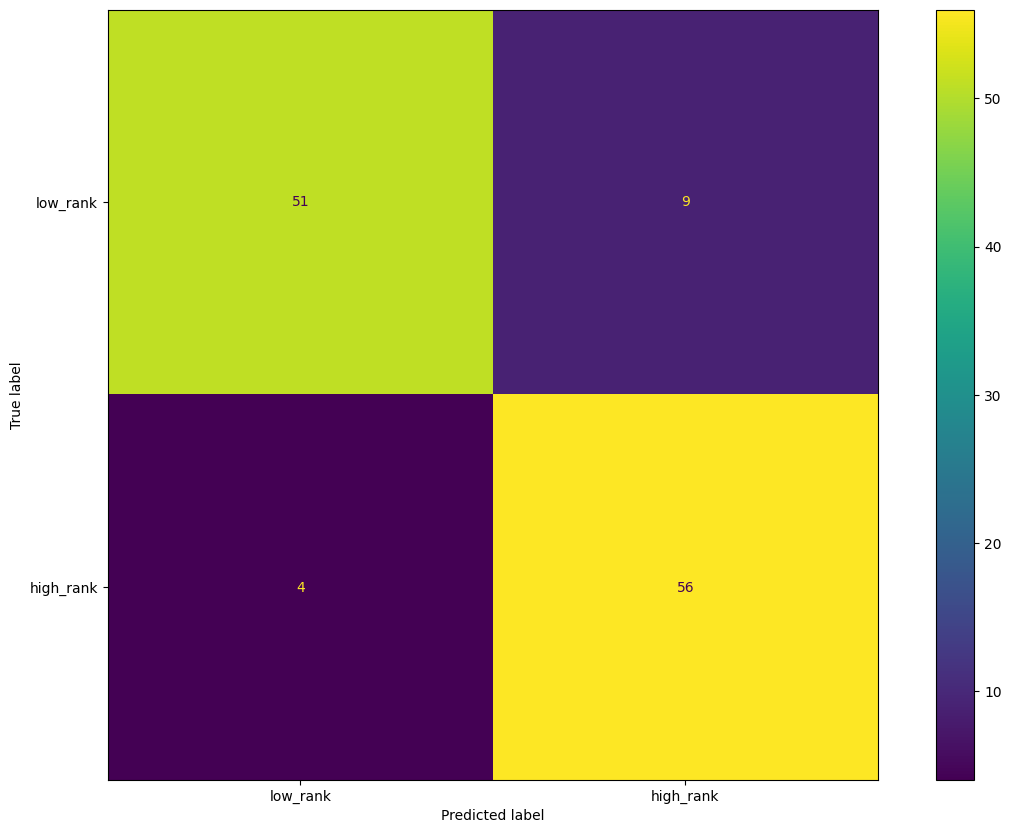

In [ ]:
print(classification_report(y_true, y_codebert_test_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_test_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_test_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_test_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

In [ ]:
# Test the model and print out the confusion matrix
model.eval()
y_true = []
y_codebert_train_pred = []
with torch.no_grad():
    for batch in train_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        y_true += labels.tolist()
        y_codebert_train_pred += predictions.tolist()

              precision    recall  f1-score   support

    low_rank       0.97      0.90      0.94       210
   high_rank       0.91      0.98      0.94       210

    accuracy                           0.94       420
   macro avg       0.94      0.94      0.94       420
weighted avg       0.94      0.94      0.94       420

f1_score_macro :  0.9380052684167499
f1_score_weighted :  0.93800526841675


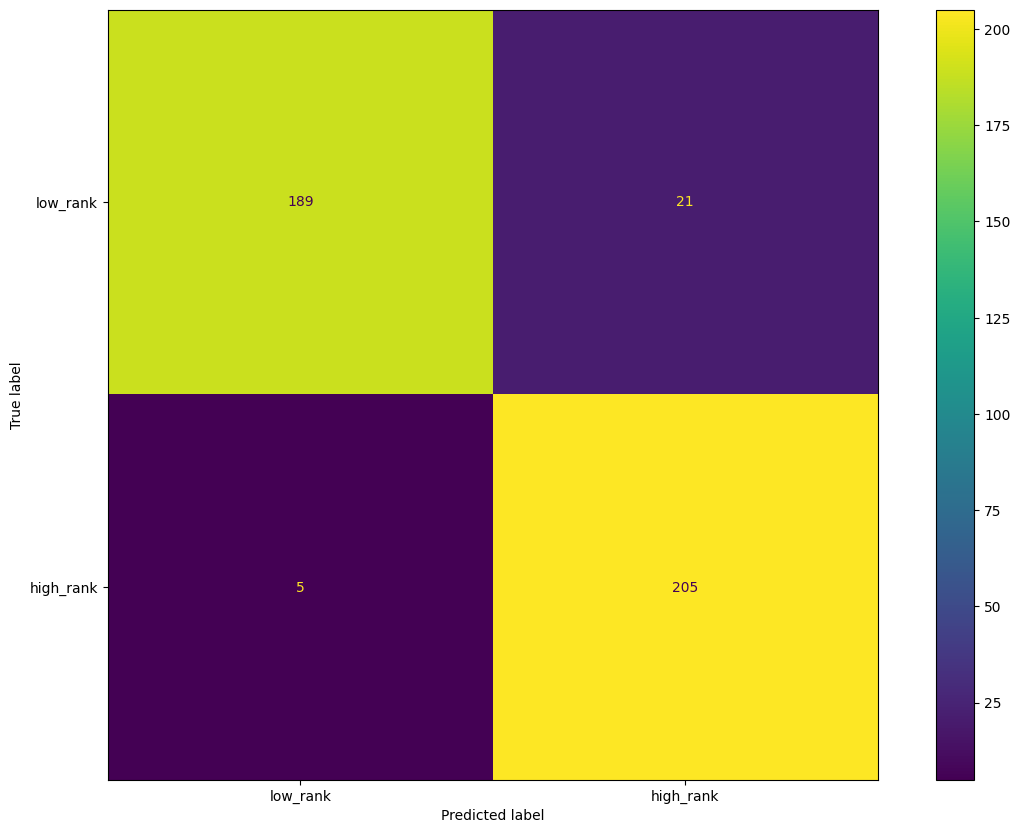

In [ ]:
print(classification_report(y_true, y_codebert_train_pred, target_names=['low_rank','high_rank']))

print("f1_score_macro : ",f1_score(y_true, y_codebert_train_pred, average='macro'))
print("f1_score_weighted : ",f1_score(y_true, y_codebert_train_pred, average='weighted'))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_true, y_codebert_train_pred), display_labels=['low_rank','high_rank'])

fig, ax = plt.subplots(figsize=(15,10))
disp.plot(ax=ax)

plt.show()

# Error Analysis

In [ ]:
test_df = leetcode_questions_df.loc[X_test_text.index]

In [ ]:
test_df['correct'] = y_codebert_test_pred == y_test

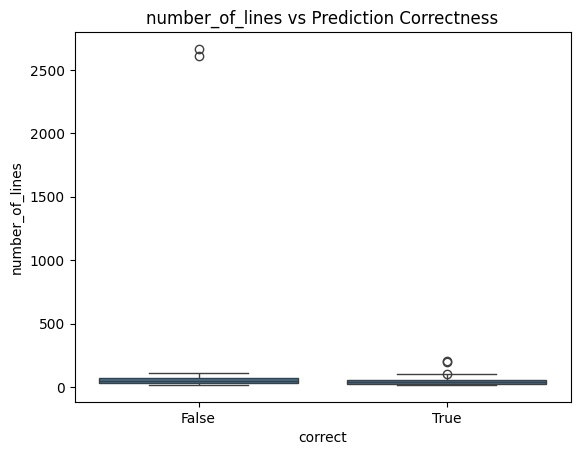

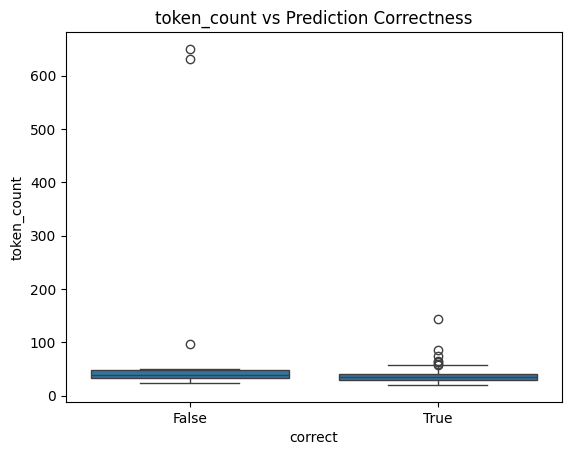

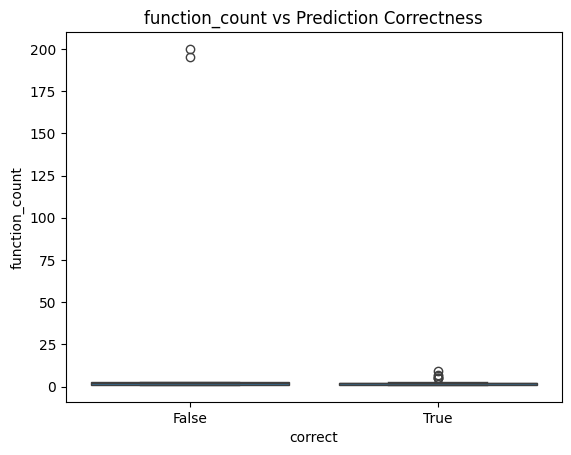

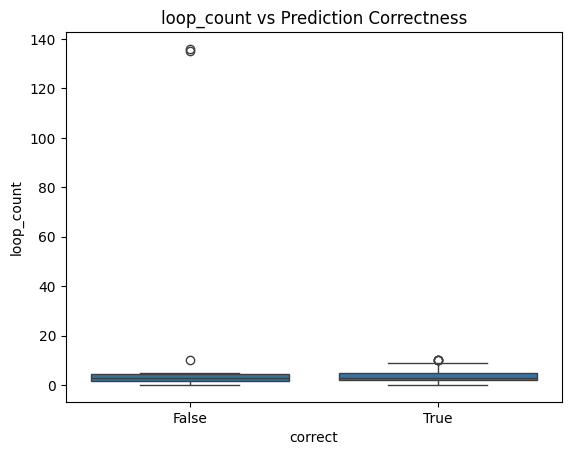

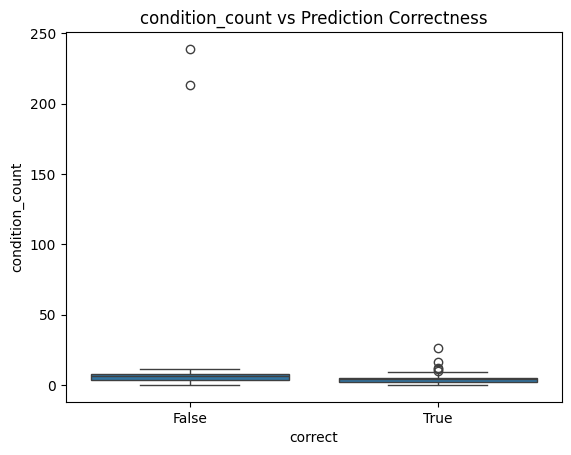

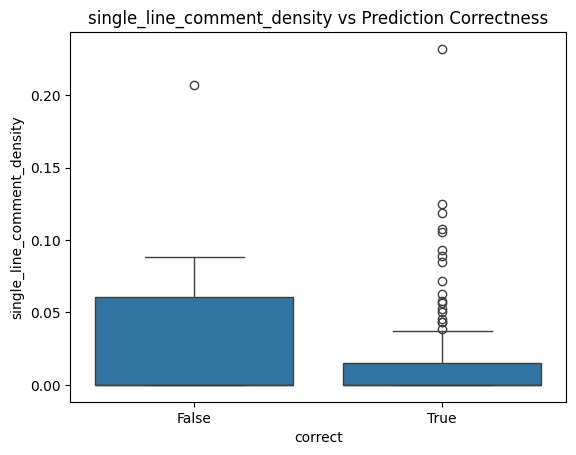

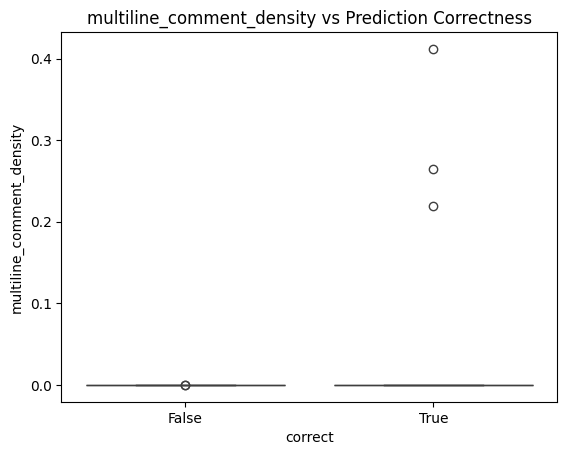

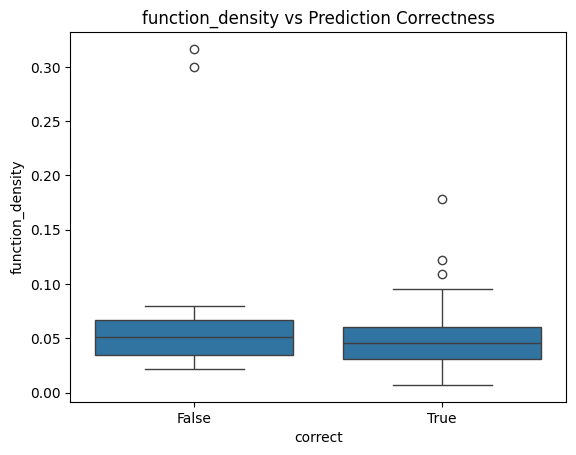

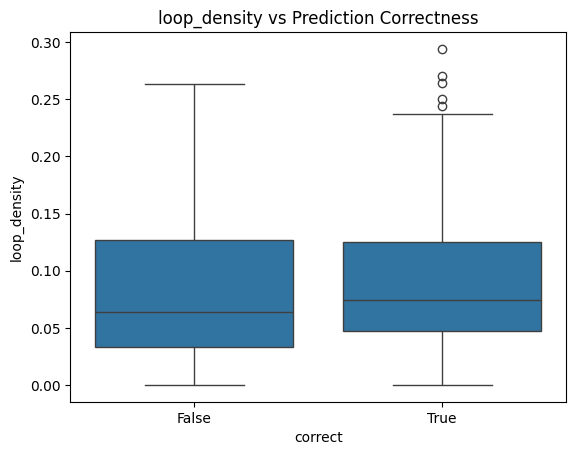

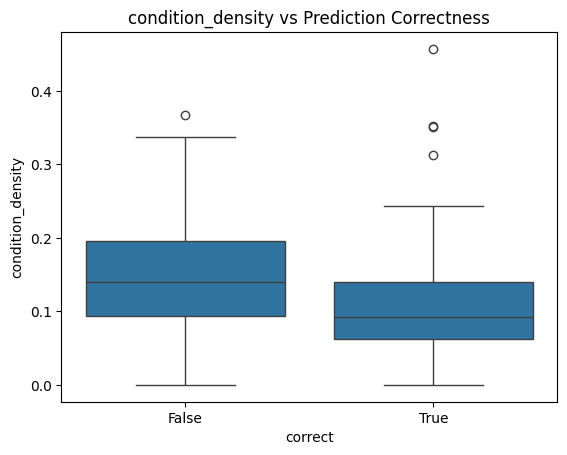

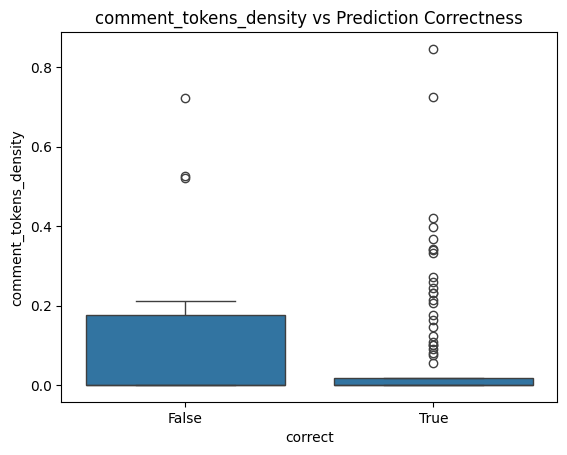

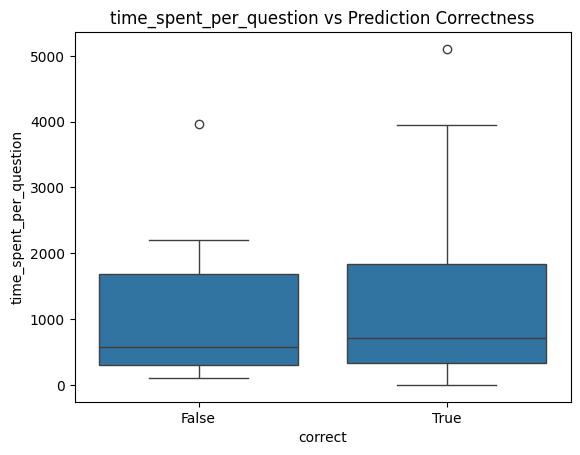

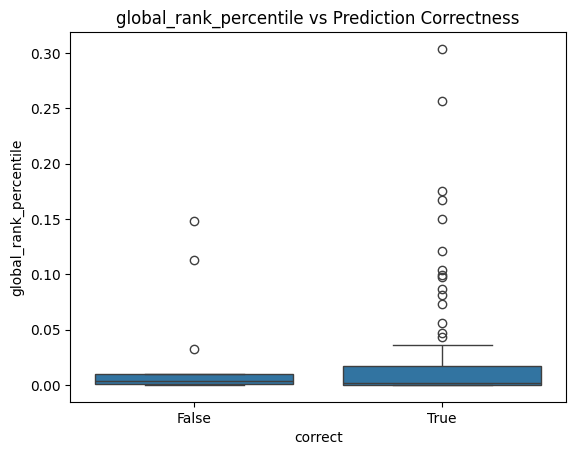

In [ ]:
features_to_plot = [
    'number_of_lines', 'token_count', 'function_count',
    'loop_count', 'condition_count',
    'single_line_comment_density', 'multiline_comment_density',
    'function_density', 'loop_density', 'condition_density',
    'comment_tokens_density', 'time_spent_per_question',
    'global_rank_percentile'
]

for col in features_to_plot:
    sns.boxplot(x='correct', y=col, data=test_df)
    plt.title(f'{col} vs Prediction Correctness')
    plt.show()

In [ ]:
test_df.groupby('correct')[features_to_plot].mean().T.sort_values(by=False, ascending=False)

correct,False,True
time_spent_per_question,1081.400000,1189.876190
number_of_lines,393.933333,45.095238
token_count,120.333333,38.571429
condition_count,34.333333,4.123810
function_count,27.866667,1.904762
loop_count,20.600000,3.371429
condition_density,0.149063,0.108397
comment_tokens_density,0.141565,0.063567
loop_density,0.096164,0.089411
function_density,0.081607,0.049815


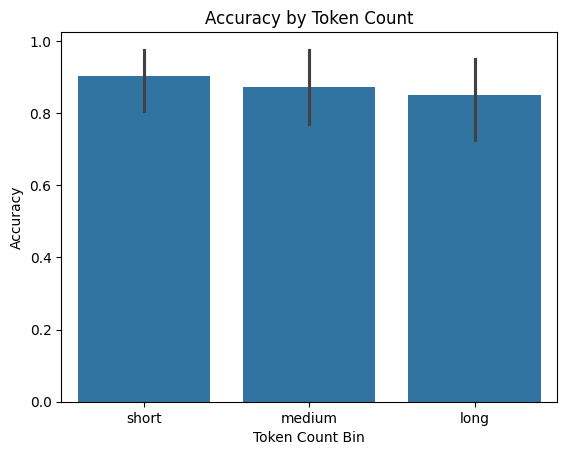

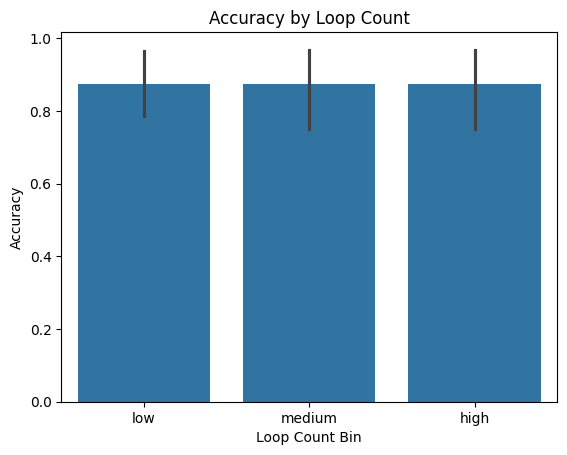

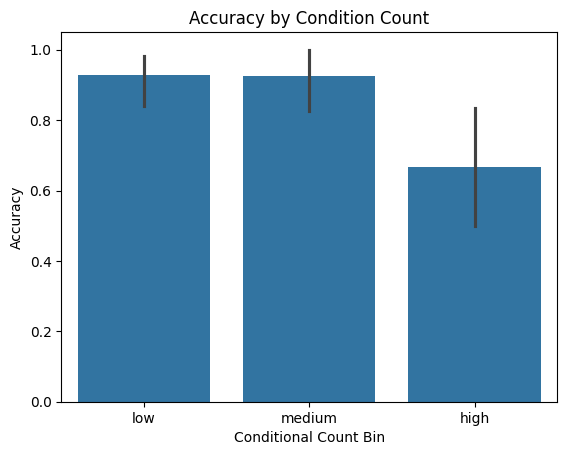

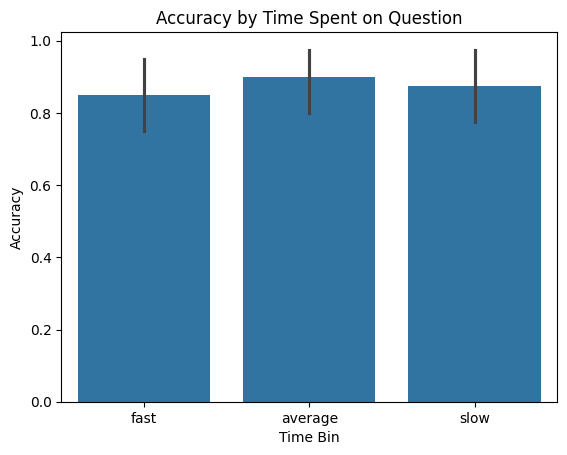

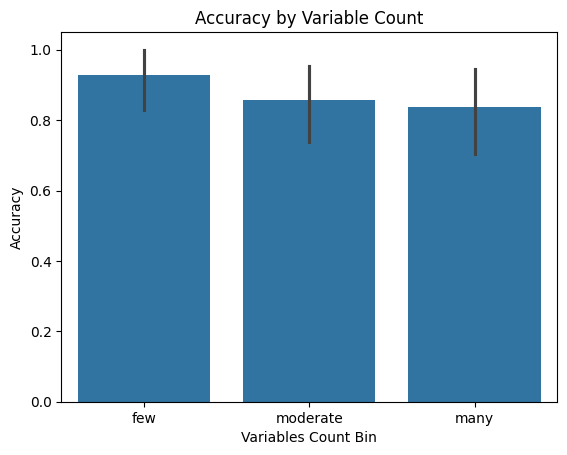

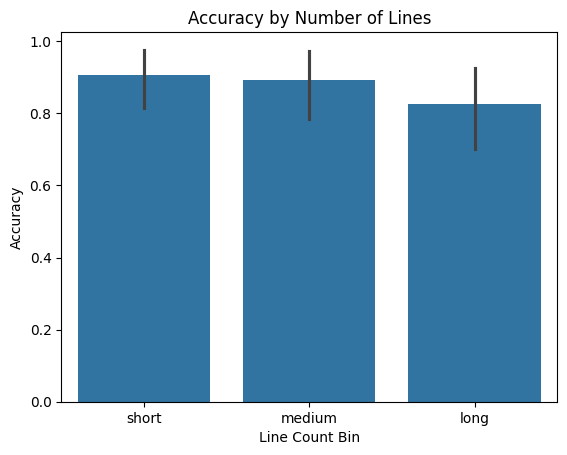

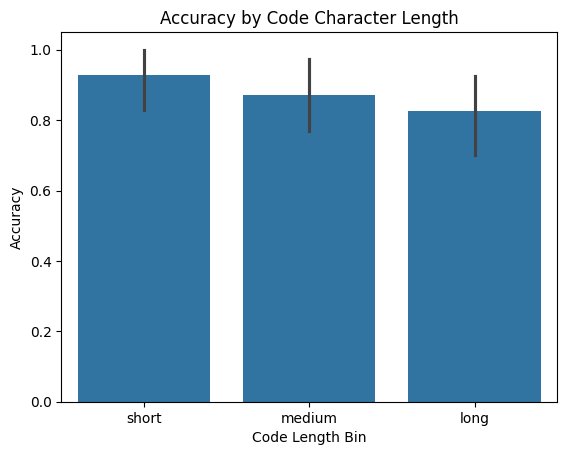

In [ ]:
import seaborn as sns

# --------------------------
# Binning Continuous Features
# --------------------------
test_df['token_bin'] = pd.qcut(test_df['token_count'], 3, labels=["short", "medium", "long"])
test_df['line_bin'] = pd.qcut(test_df['number_of_lines'], 3, labels=["short", "medium", "long"])
test_df['loop_bin'] = pd.qcut(test_df['loop_count'], 3, labels=["low", "medium", "high"])
test_df['cond_bin'] = pd.qcut(test_df['condition_count'], 3, labels=["low", "medium", "high"])
test_df['time_bin'] = pd.qcut(test_df['time_spent_per_question'], 3, labels=["fast", "average", "slow"])
test_df['var_bin'] = pd.qcut(test_df['variables_count'], 3, labels=["few", "moderate", "many"])
test_df['code_len_bin'] = pd.qcut(test_df['question_code_length'], 3, labels=["short", "medium", "long"])

# --------------------------
# 1. Barplot: Accuracy by Token Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='token_bin', y='correct')
plt.title("Accuracy by Token Count")
plt.xlabel("Token Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 2. Barplot: Accuracy by Loop Count Bin
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='loop_bin', y='correct')
plt.title("Accuracy by Loop Count")
plt.xlabel("Loop Count Bin")
plt.ylabel("Accuracy")
plt.show()


# --------------------------
# 3. Barplot: Conditional Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='cond_bin', y='correct')
plt.title("Accuracy by Condition Count")
plt.xlabel("Conditional Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 4. Barplot: Time Spent per Question
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='time_bin', y='correct')
plt.title("Accuracy by Time Spent on Question")
plt.xlabel("Time Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 5. Barplot: Variable Count
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='var_bin', y='correct')
plt.title("Accuracy by Variable Count")
plt.xlabel("Variables Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 6. Barplot: Number of Lines
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='line_bin', y='correct')
plt.title("Accuracy by Number of Lines")
plt.xlabel("Line Count Bin")
plt.ylabel("Accuracy")
plt.show()

# --------------------------
# 7. Barplot: Code Character Length
# --------------------------
plt.figure()
sns.barplot(data=test_df, x='code_len_bin', y='correct')
plt.title("Accuracy by Code Character Length")
plt.xlabel("Code Length Bin")
plt.ylabel("Accuracy")
plt.show()
